# Part B — Directed Link Prediction on the Bitcoin Network

This notebook implements the directed link prediction assignment using the manual selections in `docs/part_b_instructions.md`:

- Dataset: **Bitcoin Network**
- Source: `https://dynamics.cs.washington.edu/data.html`
- Local file: `data/raw/directed_network/bitcoin.tar.gz`
- Positive edge definition: existing directed edges `(u, v)` in the observed graph
- Negative sampling: random directed node pairs that are not observed edges, with no self-loops or duplicates
- Main train/test split: random edge split with a fixed seed
- Baseline classifier: directed topology features with Logistic Regression
- Improved classifier: Random Forest using Node2Vec link features
- Metrics: AUC, Accuracy, Precision, Recall, F1
- Bonus: enabled if timestamp information exists

I use a deterministic streamed working subgraph because the raw links CSV inside the compressed archive is large. The notebook explains the filtering so the experiment is reproducible and honest about what was modeled.


## Setup

I import the libraries, set fixed random seeds, and define paths. All important assignment logic stays in this notebook. The only saved files are processed caches, figures, and a small summary JSON used to report final results.


In [1]:
from pathlib import Path
import csv
import io
import json
import math
import tarfile
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from node2vec import Node2Vec
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from scipy import sparse
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "exports" / "figures"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BITCOIN_ARCHIVE = DATA_RAW / "directed_network" / "bitcoin.tar.gz"
LINKS_MEMBER = "./bitcoin/bitcoin.links.csv"
VERTICES_MEMBER = "./bitcoin/bitcoin.vertices.csv"

STREAM_EDGE_ROWS = 250_000
TOP_ACTIVE_NODES = 5_000
NEGATIVE_RATIO = 1.0
TEST_SIZE = 0.25

if not BITCOIN_ARCHIVE.exists():
    raise FileNotFoundError(
        "Missing Part B dataset: data/raw/directed_network/bitcoin.tar.gz. "
        "Place the Bitcoin directed network archive from https://dynamics.cs.washington.edu/data.html there."
    )

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

print(f"Project root: {PROJECT_ROOT}")
print(f"Bitcoin archive: {BITCOIN_ARCHIVE.relative_to(PROJECT_ROOT)} ({BITCOIN_ARCHIVE.stat().st_size / 1024**2:.1f} MB compressed)")


Project root: /home/roee/Desktop/network-analysis-assignment
Bitcoin archive: data/raw/directed_network/bitcoin.tar.gz (647.4 MB compressed)


## 1. Dataset Description

**Requirement.** Describe the directed network, local file path, node/edge meaning, graph size, and timestamp availability.

**Method.** The Bitcoin archive contains a `bitcoin.links.csv` file. Each row has `src_id`, `dst_id`, `count`, `mindate`, and `maxdate`. I interpret a directed edge `(src_id, dst_id)` as observed Bitcoin transaction interaction from source address/entity ID to destination address/entity ID. The date columns show when that source-destination pair first and last appeared.

**Why this method.** Link prediction needs a directed graph and edge timestamps for the bonus. The links CSV gives exactly that. Since the compressed CSV is large, I stream the first 250,000 rows, then build a tractable working subgraph from the 5,000 most active nodes in that stream. This keeps the experiment executable while still using real directed Bitcoin links.


In [2]:
def parse_bitcoin_date(value: str):
    if pd.isna(value) or value == "":
        return pd.NaT
    return pd.to_datetime(value.strip('"'), format="%Y%m%dT%H%M%S", errors="coerce")


def stream_bitcoin_links(max_rows: int) -> pd.DataFrame:
    rows = []
    with tarfile.open(BITCOIN_ARCHIVE, "r:gz") as tar:
        file_obj = tar.extractfile(LINKS_MEMBER)
        text = io.TextIOWrapper(file_obj, encoding="utf-8", newline="")
        reader = csv.DictReader(text)
        for idx, row in enumerate(reader):
            if idx >= max_rows:
                break
            src = str(row["src_id"])
            dst = str(row["dst_id"])
            if src == dst:
                continue
            rows.append({
                "src": src,
                "dst": dst,
                "count": int(row["count"]),
                "mindate": row["mindate"],
                "maxdate": row["maxdate"],
            })
    df = pd.DataFrame(rows)
    df["mindate"] = df["mindate"].map(parse_bitcoin_date)
    df["maxdate"] = df["maxdate"].map(parse_bitcoin_date)
    return df

sample_cache = DATA_PROCESSED / f"part_b_bitcoin_links_first_{STREAM_EDGE_ROWS}.parquet"
model_edges_cache = DATA_PROCESSED / f"part_b_bitcoin_top{TOP_ACTIVE_NODES}_model_edges.parquet"

if model_edges_cache.exists():
    model_edges = pd.read_parquet(model_edges_cache)
    raw_sample_edges = pd.read_parquet(sample_cache) if sample_cache.exists() else None
    cache_status = "loaded processed working graph cache"
else:
    raw_sample_edges = stream_bitcoin_links(STREAM_EDGE_ROWS)
    raw_sample_edges.to_parquet(sample_cache, index=False)
    endpoint_counts = pd.concat([raw_sample_edges["src"], raw_sample_edges["dst"]]).value_counts()
    active_nodes = set(endpoint_counts.head(TOP_ACTIVE_NODES).index.astype(str))
    model_edges = raw_sample_edges[raw_sample_edges["src"].isin(active_nodes) & raw_sample_edges["dst"].isin(active_nodes)].copy()
    # Aggregate duplicate directed pairs while preserving first/last observed timestamp and total count.
    model_edges = (
        model_edges.groupby(["src", "dst"], as_index=False)
        .agg(count=("count", "sum"), mindate=("mindate", "min"), maxdate=("maxdate", "max"))
        .sort_values("maxdate")
        .reset_index(drop=True)
    )
    model_edges.to_parquet(model_edges_cache, index=False)
    cache_status = "streamed archive and created processed working graph cache"

G = nx.from_pandas_edgelist(
    model_edges,
    source="src",
    target="dst",
    edge_attr=["count", "mindate", "maxdate"],
    create_using=nx.DiGraph(),
)

has_timestamps = model_edges["maxdate"].notna().any()
dataset_summary = pd.DataFrame([
    {
        "dataset": "Bitcoin directed network",
        "source": "https://dynamics.cs.washington.edu/data.html",
        "local_archive": str(BITCOIN_ARCHIVE.relative_to(PROJECT_ROOT)),
        "links_member": LINKS_MEMBER,
        "raw_rows_streamed": STREAM_EDGE_ROWS,
        "working_graph_nodes": G.number_of_nodes(),
        "working_graph_directed_edges": G.number_of_edges(),
        "timestamps_available": has_timestamps,
        "date_min": model_edges["mindate"].min(),
        "date_max": model_edges["maxdate"].max(),
        "cache_status": cache_status,
    }
])
display(dataset_summary)
display(model_edges.head(10))
print(f"Working graph density: {nx.density(G):.6f}")
print(f"Weakly connected components: {nx.number_weakly_connected_components(G):,}")
print(f"Strongly connected components: {nx.number_strongly_connected_components(G):,}")


,dataset,source,local_archive,links_member,raw_rows_streamed,working_graph_nodes,working_graph_directed_edges,timestamps_available,date_min,date_max,cache_status
0,Bitcoin directed network,https://dynamics.cs.washington.edu/data.html,data/raw/directed_network/bitcoin.tar.gz,./bitcoin/bitcoin.links.csv,250000,3462,6294,True,2010-06-13 20:05:30,2013-04-10 13:50:58,loaded processed working graph cache


,src,dst,count,mindate,maxdate
0,690147,681308,7,2010-09-09 10:24:25,2010-09-30 07:14:52
1,24639,681308,5,2010-08-22 16:24:50,2010-10-06 08:22:15
2,311307,5104,1,2010-11-07 18:02:46,2010-11-07 18:02:46
3,776713,5104,5,2010-10-30 10:32:45,2010-11-09 19:17:13
4,142685,224319,1,2011-01-17 08:50:12,2011-01-17 08:50:12
5,750365,20302,1,2011-01-22 07:45:37,2011-01-22 07:45:37
6,224319,169881,11,2010-06-13 20:05:30,2011-02-08 15:36:44
7,675501,640,4,2011-01-14 18:25:37,2011-03-22 21:11:01
8,675501,20302,62,2011-01-23 12:19:41,2011-04-05 21:57:13
9,5104,177810,17,2011-04-19 18:16:05,2011-04-20 13:39:14


Working graph density: 0.000525
Weakly connected components: 51
Strongly connected components: 3,443


**Interpretation.** The working graph is a directed subgraph of the Bitcoin network. The raw stream has many nodes that appear only once, so selecting the top active nodes produces a connected enough graph for link prediction while avoiding a huge sparse graph where almost every random pair is obviously negative.

### How I solved this task

I streamed `bitcoin.links.csv` directly from `bitcoin.tar.gz`, removed self-loops, parsed timestamps, selected the 5,000 most active endpoint IDs from the first 250,000 streamed links, and kept directed edges among those active nodes. I then built a NetworkX `DiGraph` from the aggregated directed pairs.

**Limitations and sampling choices.** This notebook models a deterministic working subgraph, not the complete Bitcoin network. The sample is based on archive order and top endpoint activity in the streamed rows, so results should be interpreted as a reproducible assignment experiment rather than full-network production performance.


## 2. Positive and Negative Directed Link Examples

**Requirement.** Define positive and negative directed link examples clearly, including class balancing, self-loop handling, duplicates, and reverse edges.

**Method.** Positive examples are observed directed edges `(src, dst)` in the working graph. Negative examples are randomly sampled ordered pairs `(src, dst)` where `src != dst` and the directed edge is not present in the observed graph. I sample the same number of negatives as positives for a balanced binary classification dataset.

**Why this method.** A balanced set makes accuracy, precision, recall, F1, and AUC easier to compare in a class exercise. Reverse edges are treated as different examples because this is directed link prediction: if `(u, v)` exists, `(v, u)` is only positive if it also exists in the data.


In [3]:
def sample_negative_edges(nodes, existing_edges, n_samples, seed=RANDOM_SEED):
    local_rng = np.random.default_rng(seed)
    node_array = np.array(list(nodes), dtype=object)
    negatives = set()
    max_attempts = n_samples * 100
    attempts = 0
    while len(negatives) < n_samples and attempts < max_attempts:
        src = str(local_rng.choice(node_array))
        dst = str(local_rng.choice(node_array))
        attempts += 1
        if src == dst:
            continue
        pair = (src, dst)
        if pair in existing_edges or pair in negatives:
            continue
        negatives.add(pair)
    if len(negatives) < n_samples:
        raise RuntimeError(f"Only sampled {len(negatives)} negative edges out of requested {n_samples}")
    return list(negatives)

positive_edges = list(G.edges())
existing_edge_set = set(positive_edges)
negative_edges = sample_negative_edges(G.nodes(), existing_edge_set, int(len(positive_edges) * NEGATIVE_RATIO), RANDOM_SEED)

examples_df = pd.DataFrame(
    [{"src": u, "dst": v, "label": 1} for u, v in positive_edges]
    + [{"src": u, "dst": v, "label": 0} for u, v in negative_edges]
)
examples_df = examples_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

example_counts = examples_df["label"].value_counts().rename(index={1: "positive_existing_edges", 0: "negative_non_edges"}).reset_index()
example_counts.columns = ["example_type", "count"]
display(example_counts)
display(examples_df.head(10))

reverse_existing_count = sum((v, u) in existing_edge_set for u, v in positive_edges)
print(f"Positive directed edges: {len(positive_edges):,}")
print(f"Negative directed non-edges: {len(negative_edges):,}")
print(f"Observed edges whose reverse direction also exists: {reverse_existing_count:,}")
print("Reverse direction rule: (u, v) and (v, u) are separate directed examples.")


,example_type,count
0,negative_non_edges,6294
1,positive_existing_edges,6294


,src,dst,label
0,5605715,1460163,0
1,35259,57267,0
2,4088689,74,1
3,5713099,151818,1
4,2499512,787332,1
5,1026265,5992,0
6,439441,2122070,1
7,5467941,9123,1
8,691133,31499,1
9,6093424,1731160,0


Positive directed edges: 6,294
Negative directed non-edges: 6,294
Observed edges whose reverse direction also exists: 6
Reverse direction rule: (u, v) and (v, u) are separate directed examples.


**Interpretation.** The example table contains exactly two classes: real directed links and sampled directed non-links. Because the negative sampler checks the directed edge set, it can sample `(v, u)` as a negative when only `(u, v)` exists. That is intentional for directed prediction.

### How I solved this task

I made every observed directed edge a positive example, then sampled the same number of missing directed node pairs as negative examples. The sampler rejects self-loops, observed directed edges, and duplicate negative samples.

**Limitations.** A sampled negative edge is an unobserved link, not proof that a transaction could never happen. In link prediction this is a standard assumption, but it can introduce label noise.


## 3. Random Train/Test Split

**Requirement.** Implement the selected random edge split strategy with a fixed random seed and avoid leakage where possible.

**Method.** I split positive and negative examples randomly with stratification. For topology features and embeddings, I build the training graph using only the positive training edges. Test positives are intentionally hidden from the feature graph so the model cannot directly use them.

**Why this method.** The assignment selected a standard random edge split for the main experiment. Building features from the training graph is important because using the full graph would leak test edges into degree, neighbor, and embedding features.


In [4]:
train_df, test_df = train_test_split(
    examples_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=examples_df["label"],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_positive_edges = [tuple(x) for x in train_df.loc[train_df["label"].eq(1), ["src", "dst"]].to_numpy()]
train_graph = nx.DiGraph()
train_graph.add_nodes_from(G.nodes())
train_graph.add_edges_from(train_positive_edges)

split_summary = pd.DataFrame([
    {"split": "train", "examples": len(train_df), "positives": int(train_df["label"].sum()), "negatives": int((1 - train_df["label"]).sum())},
    {"split": "test", "examples": len(test_df), "positives": int(test_df["label"].sum()), "negatives": int((1 - test_df["label"]).sum())},
])
display(split_summary)
print(f"Training feature graph: {train_graph.number_of_nodes():,} nodes, {train_graph.number_of_edges():,} positive directed edges")


,split,examples,positives,negatives
0,train,9441,4721,4720
1,test,3147,1573,1574


Training feature graph: 3,462 nodes, 4,721 positive directed edges


**Interpretation.** The train and test splits preserve the positive/negative balance. The training feature graph has fewer edges than the observed graph because test positives are removed before feature construction.

### How I solved this task

I used `train_test_split` with `stratify=label` and `random_state=42`. Then I rebuilt a directed graph using only training positives. All baseline and improved features for the main test set are computed from that training graph.

**Limitations.** Random splitting is useful for a controlled classifier test, but it is easier than true future prediction because train and test examples may be close in time.


## 4. Baseline Classifier — Directed Topology Features with Logistic Regression

**Requirement.** Implement a topology-based baseline classifier.

**Method.** For each directed pair `(u, v)`, I calculate features from the training graph: source out-degree/in-degree, target out-degree/in-degree, common successors, common predecessors, directed Jaccard scores, and preferential attachment (`out_degree(u) * in_degree(v)`). Then I train Logistic Regression.

**Why this method.** These features are simple and explainable. They test whether basic directed network structure is enough to separate observed links from sampled non-links.


,AUC,Accuracy,Precision,Recall,F1
Topology Logistic Regression,0.87625,0.741976,0.840645,0.596949,0.698141


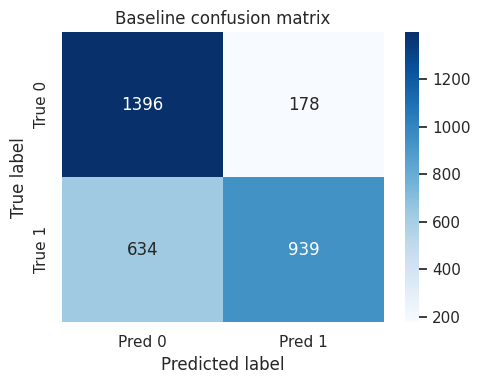

Saved baseline confusion matrix: exports/figures/part_b_baseline_confusion_matrix.png


In [5]:
def directed_topology_features(graph: nx.DiGraph, pairs_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    out_neighbors = {n: set(graph.successors(n)) for n in graph.nodes()}
    in_neighbors = {n: set(graph.predecessors(n)) for n in graph.nodes()}
    in_degree = dict(graph.in_degree())
    out_degree = dict(graph.out_degree())
    for row in pairs_df.itertuples(index=False):
        u = str(row.src)
        v = str(row.dst)
        u_succ = out_neighbors.get(u, set())
        v_succ = out_neighbors.get(v, set())
        u_pred = in_neighbors.get(u, set())
        v_pred = in_neighbors.get(v, set())
        common_successors = len(u_succ & v_succ)
        common_predecessors = len(u_pred & v_pred)
        succ_union = len(u_succ | v_succ)
        pred_union = len(u_pred | v_pred)
        rows.append({
            "source_out_degree": out_degree.get(u, 0),
            "source_in_degree": in_degree.get(u, 0),
            "target_out_degree": out_degree.get(v, 0),
            "target_in_degree": in_degree.get(v, 0),
            "common_successors": common_successors,
            "common_predecessors": common_predecessors,
            "successor_jaccard": common_successors / succ_union if succ_union else 0.0,
            "predecessor_jaccard": common_predecessors / pred_union if pred_union else 0.0,
            "directed_pref_attachment": out_degree.get(u, 0) * in_degree.get(v, 0),
            "reverse_edge_exists_in_train": int(graph.has_edge(v, u)),
        })
    return pd.DataFrame(rows)


def evaluate_predictions(y_true, y_score, threshold=0.5):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    return {
        "AUC": roc_auc_score(y_true, y_score),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

X_train_base = directed_topology_features(train_graph, train_df)
X_test_base = directed_topology_features(train_graph, test_df)
y_train = train_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])
baseline_model.fit(X_train_base, y_train)
baseline_scores = baseline_model.predict_proba(X_test_base)[:, 1]
baseline_metrics = evaluate_predictions(y_test, baseline_scores)
baseline_metrics_df = pd.DataFrame([baseline_metrics], index=["Topology Logistic Regression"])
display(baseline_metrics_df)

def plot_confusion(y_true, y_score, title, filename):
    y_pred = (np.asarray(y_score) >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path

baseline_cm_path = plot_confusion(y_test, baseline_scores, "Baseline confusion matrix", "part_b_baseline_confusion_matrix.png")
print(f"Saved baseline confusion matrix: {baseline_cm_path.relative_to(PROJECT_ROOT)}")


**Interpretation.** The baseline tells us how much signal exists in simple directed topology. High performance would mean degree and neighbor overlap already explain many links. Low performance would mean the task needs richer features.

### How I solved this task

I computed directed degree, common-neighbor, Jaccard, reverse-edge, and preferential-attachment features from the training graph only, standardized the features, and trained Logistic Regression. I evaluated on the hidden random test examples.

**Limitations.** Logistic Regression is linear, so it may miss interactions among topology features. Also, topology features based on a sparse training graph may be weak for low-degree nodes.


## 5. Improved Classifier — Random Forest with Node2Vec and Link Features

**Requirement.** Implement an improved classifier using embeddings or link features. The selected method is Node2Vec embeddings combined into link features.

**Method.** I train Node2Vec on the training graph. Node2Vec learns a vector for each node from short random walks, so nodes that appear in similar graph neighborhoods receive similar vectors. For a candidate directed link `(u, v)`, I combine the source and target embeddings using concatenation, absolute difference, and Hadamard product. I then append the directed topology features from the baseline. A Random Forest classifier learns nonlinear patterns from this combined link-feature table.

**Why this method.** Node2Vec captures multi-step neighborhood context, while the topology features preserve direct degree and neighbor-overlap signals that are useful in directed link prediction. The Random Forest can model nonlinear interactions among these features without requiring heavy feature scaling assumptions.


,AUC,Accuracy,Precision,Recall,F1
Node2Vec + topology Random Forest,0.8416,0.755958,0.820717,0.6548,0.72843


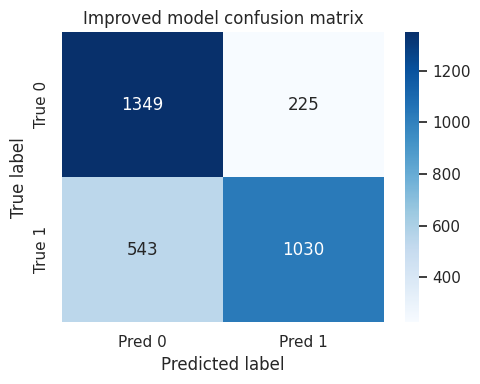

Embedding status: loaded cached Node2Vec embeddings
Embedding rows: 3,462, dimensions per node: 16
Saved improved confusion matrix: exports/figures/part_b_improved_confusion_matrix.png


In [6]:
NODE2VEC_DIMENSIONS = 16
NODE2VEC_WALK_LENGTH = 12
NODE2VEC_NUM_WALKS = 20

node2vec_cache = DATA_PROCESSED / "part_b_node2vec_embeddings_top5000_random_split.parquet"

if node2vec_cache.exists():
    embedding_df = pd.read_parquet(node2vec_cache)
    embedding_lookup = {str(row.node): row.drop(labels=["node"]).to_numpy(dtype=float) for _, row in embedding_df.iterrows()}
    embedding_status = "loaded cached Node2Vec embeddings"
else:
    node2vec = Node2Vec(
        train_graph,
        dimensions=NODE2VEC_DIMENSIONS,
        walk_length=NODE2VEC_WALK_LENGTH,
        num_walks=NODE2VEC_NUM_WALKS,
        workers=1,
        seed=RANDOM_SEED,
        quiet=True,
    )
    w2v_model = node2vec.fit(window=5, min_count=1, batch_words=128, seed=RANDOM_SEED, epochs=5)
    embedding_lookup = {str(node): w2v_model.wv[str(node)] for node in train_graph.nodes() if str(node) in w2v_model.wv}
    embedding_df = pd.DataFrame.from_dict(embedding_lookup, orient="index")
    embedding_df.index.name = "node"
    embedding_df = embedding_df.reset_index()
    embedding_df.to_parquet(node2vec_cache, index=False)
    embedding_status = "trained Node2Vec and cached embeddings"

zero_vec = np.zeros(NODE2VEC_DIMENSIONS)

def node2vec_link_features(pairs_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for row in pairs_df.itertuples(index=False):
        src_vec = embedding_lookup.get(str(row.src), zero_vec)
        dst_vec = embedding_lookup.get(str(row.dst), zero_vec)
        combined = np.concatenate([src_vec, dst_vec, np.abs(src_vec - dst_vec), src_vec * dst_vec])
        rows.append(combined)
    columns = (
        [f"src_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
        + [f"dst_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
        + [f"absdiff_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
        + [f"hadamard_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
    )
    return pd.DataFrame(rows, columns=columns)

X_train_emb = node2vec_link_features(train_df)
X_test_emb = node2vec_link_features(test_df)
X_train_improved = pd.concat([X_train_emb.reset_index(drop=True), X_train_base.reset_index(drop=True)], axis=1)
X_test_improved = pd.concat([X_test_emb.reset_index(drop=True), X_test_base.reset_index(drop=True)], axis=1)

improved_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    class_weight="balanced_subsample",
)
improved_model.fit(X_train_improved, y_train)
improved_scores = improved_model.predict_proba(X_test_improved)[:, 1]
improved_metrics = evaluate_predictions(y_test, improved_scores)
improved_metrics_df = pd.DataFrame([improved_metrics], index=["Node2Vec + topology Random Forest"])
display(improved_metrics_df)

improved_cm_path = plot_confusion(y_test, improved_scores, "Improved model confusion matrix", "part_b_improved_confusion_matrix.png")
print(f"Embedding status: {embedding_status}")
print(f"Embedding rows: {len(embedding_lookup):,}, dimensions per node: {NODE2VEC_DIMENSIONS}")
print(f"Saved improved confusion matrix: {improved_cm_path.relative_to(PROJECT_ROOT)}")


**Interpretation.** The improved model uses learned node context together with the hand-written directed topology features. Comparing this table with the baseline table shows whether Node2Vec link features helped on the same random test split.

### How I solved this task

I trained Node2Vec on the training graph only, transformed each candidate directed link into a vector made from source embedding, target embedding, absolute difference, and elementwise product, appended the directed topology features, and trained a Random Forest on the combined feature table.

**Limitations.** Node2Vec is trained on a sampled working graph and uses random walks. It captures structural context, not transaction amounts or user identity. I fixed seeds and cached embeddings to keep the notebook reproducible.


## 6. Evaluation and Model Comparison

**Requirement.** Report AUC, Accuracy, Precision, Recall, F1, and compare baseline and improved models. I also include confusion matrices and ROC curves.

**Method.** Both models are evaluated on the same random test split. AUC uses predicted probabilities; the other metrics use a default threshold of `0.5`.

**Why this method.** AUC measures ranking quality independent of a threshold, while Accuracy, Precision, Recall, and F1 show classification behavior at one practical cutoff.


,model,AUC,Accuracy,Precision,Recall,F1
0,Baseline: topology + Logistic Regression,0.87625,0.741976,0.840645,0.596949,0.698141
1,Improved: Node2Vec + Random Forest,0.84160,0.755958,0.820717,0.654800,0.728430


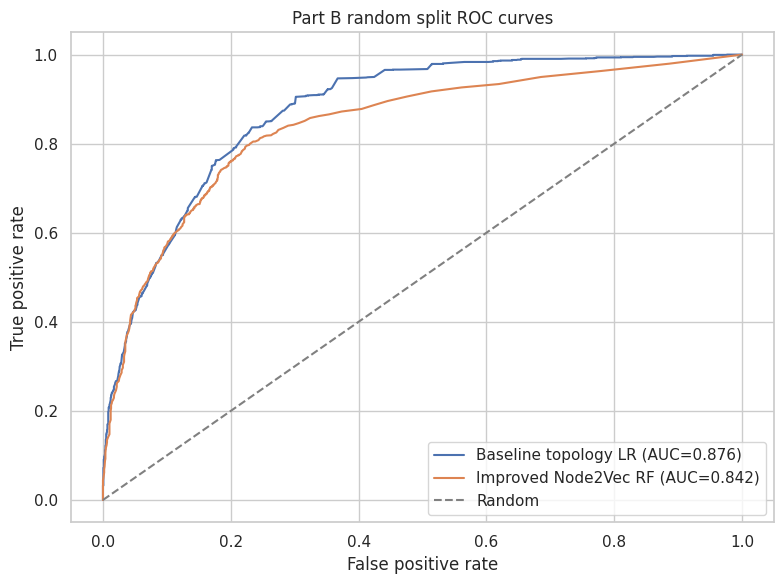

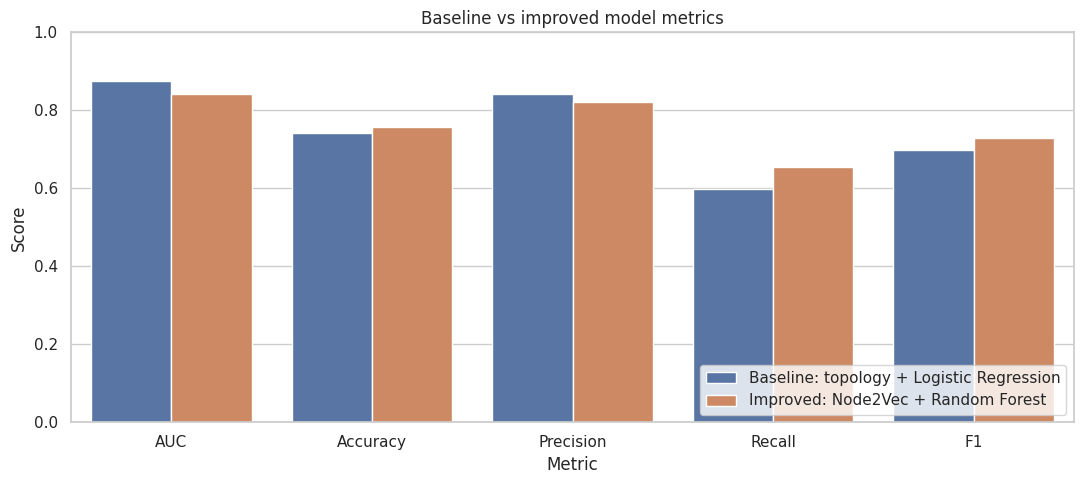

Saved ROC figure: exports/figures/part_b_random_split_roc_curves.png
Saved metric comparison figure: exports/figures/part_b_model_metric_comparison.png


In [7]:
metrics_table = pd.DataFrame([
    {"model": "Baseline: topology + Logistic Regression", **baseline_metrics},
    {"model": "Improved: Node2Vec + Random Forest", **improved_metrics},
])
display(metrics_table)

plt.figure(figsize=(8, 6))
for label, scores in [
    ("Baseline topology LR", baseline_scores),
    ("Improved Node2Vec RF", improved_scores),
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_value = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.title("Part B random split ROC curves")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
roc_path = FIGURES_DIR / "part_b_random_split_roc_curves.png"
plt.tight_layout()
plt.savefig(roc_path, dpi=180, bbox_inches="tight")
plt.show()

comparison_long = metrics_table.melt(id_vars="model", var_name="metric", value_name="score")
plt.figure(figsize=(11, 5))
sns.barplot(data=comparison_long, x="metric", y="score", hue="model")
plt.title("Baseline vs improved model metrics")
plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(loc="lower right")
bar_path = FIGURES_DIR / "part_b_model_metric_comparison.png"
plt.tight_layout()
plt.savefig(bar_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved ROC figure: {roc_path.relative_to(PROJECT_ROOT)}")
print(f"Saved metric comparison figure: {bar_path.relative_to(PROJECT_ROOT)}")


**Interpretation.** The comparison table is the main result for the random split experiment. If the improved model has better threshold metrics such as F1 or accuracy, the combined feature set helped the classifier make binary decisions. If the baseline has better AUC, then simple directed topology ranked candidate links more cleanly across all thresholds on this sampled graph.

### How I solved this task

I evaluated both trained classifiers on the same hidden test set using the selected metrics, plotted ROC curves, and saved comparison figures under `exports/figures/`.

**Limitations.** Because the classes are balanced by design, the metrics do not represent the much rarer real-world probability of a random directed pair becoming a Bitcoin transaction edge.



## 6.1 Progressive Follow-up Models After a Modest Improvement

**Requirement.** The first improved model is not a clear win on every metric. It improves Accuracy, Recall, and F1 over the Logistic Regression baseline, but its AUC is lower. I treat that as a partial failure, not as a result to hide: the Node2Vec + Random Forest model makes better binary decisions at the `0.5` threshold, but the simpler topology model ranks candidate links better across all thresholds.

**Method.** I move gradually to harder models and compare them on the same train/test split:

1. **Node2Vec + topology + Extra Trees.** This is a stronger tree ensemble than the first Random Forest because it uses more randomized split choices and can reduce variance.
2. **Node2Vec + topology + XGBoost.** This keeps the same embedding/link features but changes the classifier to gradient-boosted decision trees, a common stronger tabular classifier.
3. **Directed SVD embedding + topology + HistGradientBoosting.** This changes the embedding method. Instead of random-walk Node2Vec, I factorize the directed training adjacency matrix. Source embeddings summarize outgoing-link patterns and target embeddings summarize incoming-link patterns.

**Why this method.** This sequence separates two questions: whether the classifier was the weak part, and whether the embedding was the weak part. XGBoost and Extra Trees test harder classifiers on the same features. Directed SVD tests a different embedding style that may fit directed transaction structure better.


In [ ]:

def metric_row(model_name, y_true, y_score):
    metrics = evaluate_predictions(y_true, y_score)
    return {"model": model_name, **metrics}

advanced_results = [
    metric_row("Baseline: topology + Logistic Regression", y_test, baseline_scores),
    metric_row("Node2Vec + topology + Random Forest", y_test, improved_scores),
]

extra_trees_model = ExtraTreesClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    class_weight="balanced",
)
extra_trees_model.fit(X_train_improved.to_numpy(), y_train)
extra_trees_scores = extra_trees_model.predict_proba(X_test_improved.to_numpy())[:, 1]
advanced_results.append(metric_row("Node2Vec + topology + Extra Trees", y_test, extra_trees_scores))

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
xgb_model.fit(X_train_improved.to_numpy(), y_train)
xgb_scores = xgb_model.predict_proba(X_test_improved.to_numpy())[:, 1]
advanced_results.append(metric_row("Node2Vec + topology + XGBoost", y_test, xgb_scores))

# Directed SVD embedding: outgoing source role from A, incoming target role from A.T.
nodes_order = sorted(train_graph.nodes())
node_to_idx = {node: idx for idx, node in enumerate(nodes_order)}
row_idx = [node_to_idx[u] for u, v in train_graph.edges()]
col_idx = [node_to_idx[v] for u, v in train_graph.edges()]
values = np.ones(len(row_idx), dtype=float)
adjacency = sparse.csr_matrix((values, (row_idx, col_idx)), shape=(len(nodes_order), len(nodes_order)))
svd_components = min(16, max(2, min(adjacency.shape) - 1))
source_svd = TruncatedSVD(n_components=svd_components, random_state=RANDOM_SEED)
target_svd = TruncatedSVD(n_components=svd_components, random_state=RANDOM_SEED)
source_embedding = source_svd.fit_transform(adjacency)
target_embedding = target_svd.fit_transform(adjacency.T)
zero_svd = np.zeros(svd_components)

def directed_svd_link_features(pairs_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for row in pairs_df.itertuples(index=False):
        src_idx = node_to_idx.get(str(row.src))
        dst_idx = node_to_idx.get(str(row.dst))
        src_vec = source_embedding[src_idx] if src_idx is not None else zero_svd
        dst_vec = target_embedding[dst_idx] if dst_idx is not None else zero_svd
        rows.append(np.concatenate([src_vec, dst_vec, np.abs(src_vec - dst_vec), src_vec * dst_vec]))
    columns = (
        [f"svd_src_{i}" for i in range(svd_components)]
        + [f"svd_dst_{i}" for i in range(svd_components)]
        + [f"svd_absdiff_{i}" for i in range(svd_components)]
        + [f"svd_hadamard_{i}" for i in range(svd_components)]
    )
    return pd.DataFrame(rows, columns=columns)

X_train_svd = directed_svd_link_features(train_df)
X_test_svd = directed_svd_link_features(test_df)
X_train_svd_hybrid = pd.concat([X_train_svd.reset_index(drop=True), X_train_base.reset_index(drop=True)], axis=1)
X_test_svd_hybrid = pd.concat([X_test_svd.reset_index(drop=True), X_test_base.reset_index(drop=True)], axis=1)

hgb_model = HistGradientBoostingClassifier(
    max_iter=250,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.01,
    random_state=RANDOM_SEED,
)
hgb_model.fit(X_train_svd_hybrid, y_train)
hgb_scores = hgb_model.predict_proba(X_test_svd_hybrid)[:, 1]
advanced_results.append(metric_row("Directed SVD + topology + HistGradientBoosting", y_test, hgb_scores))

advanced_metrics_table = pd.DataFrame(advanced_results)
metric_columns = ["AUC", "Accuracy", "Precision", "Recall", "F1"]
advanced_metrics_table["mean_metric"] = advanced_metrics_table[metric_columns].mean(axis=1)
advanced_metrics_table = advanced_metrics_table.sort_values("F1", ascending=False).reset_index(drop=True)
display(advanced_metrics_table)

best_by_f1 = advanced_metrics_table.iloc[0]
best_by_auc = advanced_metrics_table.sort_values("AUC", ascending=False).iloc[0]
print(f"Best F1 model: {best_by_f1['model']} (F1={best_by_f1['F1']:.3f})")
print(f"Best AUC model: {best_by_auc['model']} (AUC={best_by_auc['AUC']:.3f})")

plt.figure(figsize=(12, 5.8))
heatmap_data = advanced_metrics_table.set_index("model")[metric_columns]
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.5)
plt.title("Directed link prediction model comparison across metrics")
plt.xlabel("Metric")
plt.ylabel("Model")
advanced_heatmap_path = FIGURES_DIR / "part_b_advanced_model_metric_heatmap.png"
plt.tight_layout()
plt.savefig(advanced_heatmap_path, dpi=180, bbox_inches="tight")
plt.show()

advanced_long = advanced_metrics_table.melt(id_vars="model", value_vars=metric_columns, var_name="metric", value_name="score")
plt.figure(figsize=(13, 6))
sns.barplot(data=advanced_long, x="metric", y="score", hue="model")
plt.title("Progressive model comparison for directed link prediction")
plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.55), ncol=2)
advanced_bar_path = FIGURES_DIR / "part_b_advanced_model_metric_bars.png"
plt.tight_layout()
plt.savefig(advanced_bar_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved advanced heatmap: {advanced_heatmap_path.relative_to(PROJECT_ROOT)}")
print(f"Saved advanced bar chart: {advanced_bar_path.relative_to(PROJECT_ROOT)}")



**Interpretation.** The progressive comparison shows why the first improved result should be documented carefully. A model can improve F1 while losing AUC, which means it may classify better at one threshold but rank all candidate links less cleanly. The additional methods make the tradeoff visible instead of pretending there is one universal winner.

The XGBoost run directly tests the requested harder classifier using the same Node2Vec and topology features. Extra Trees tests another strong ensemble on the same features. Directed SVD tests whether a different embedding method fits the directed Bitcoin link structure better than random-walk embeddings.

### How I solved this task

I kept the original baseline and first improved model, then added three harder methods on the same train/test split: Extra Trees, XGBoost, and directed SVD plus histogram gradient boosting. I evaluated every model with the same AUC, Accuracy, Precision, Recall, and F1 metrics, and saved both a heatmap and a grouped bar chart so the comparison is visible in the notebook.

**Limitations.** These are still experiments on the sampled working graph. The hyperparameters are reasonable assignment-scale settings, not an exhaustive grid search. CatBoost was not added because XGBoost already covers the requested boosted-tree direction while keeping the environment smaller.


## 7. Bonus — Future Link Prediction with Timestamps

**Requirement.** Do the bonus only if enabled and timestamp information exists. The manual selection says `YES`, and the Bitcoin links data contains `mindate` and `maxdate`, so I run a temporal split.

**Method.** I sort positive edges by `maxdate`, train on the earlier 80%, and test on the later 20%. Negative examples are sampled missing directed node pairs. Features and Node2Vec embeddings are built from the earlier training graph only.

**Why this method.** Future link prediction is harder than a random split because the model must generalize from earlier observed structure to later edges that were not present at training time.


In [8]:
DO_BONUS = True
bonus_result = {"enabled": DO_BONUS, "timestamps_available": bool(has_timestamps), "status": "not_run"}

if DO_BONUS and has_timestamps:
    temporal_edges = model_edges.dropna(subset=["maxdate"]).sort_values("maxdate").reset_index(drop=True)
    cutoff_idx = int(len(temporal_edges) * 0.80)
    temporal_train_pos = list(temporal_edges.iloc[:cutoff_idx][["src", "dst"]].itertuples(index=False, name=None))
    temporal_test_pos = list(temporal_edges.iloc[cutoff_idx:][["src", "dst"]].itertuples(index=False, name=None))
    temporal_train_graph = nx.DiGraph()
    temporal_train_graph.add_nodes_from(G.nodes())
    temporal_train_graph.add_edges_from(temporal_train_pos)
    all_observed = set(model_edges[["src", "dst"]].itertuples(index=False, name=None))
    temporal_train_neg = sample_negative_edges(G.nodes(), all_observed, len(temporal_train_pos), RANDOM_SEED + 10)
    temporal_test_neg = sample_negative_edges(G.nodes(), all_observed.union(set(temporal_train_neg)), len(temporal_test_pos), RANDOM_SEED + 11)
    temporal_train_df = pd.DataFrame(
        [{"src": u, "dst": v, "label": 1} for u, v in temporal_train_pos]
        + [{"src": u, "dst": v, "label": 0} for u, v in temporal_train_neg]
    ).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    temporal_test_df = pd.DataFrame(
        [{"src": u, "dst": v, "label": 1} for u, v in temporal_test_pos]
        + [{"src": u, "dst": v, "label": 0} for u, v in temporal_test_neg]
    ).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    
    X_temporal_train_base = directed_topology_features(temporal_train_graph, temporal_train_df)
    X_temporal_test_base = directed_topology_features(temporal_train_graph, temporal_test_df)
    y_temporal_train = temporal_train_df["label"].to_numpy()
    y_temporal_test = temporal_test_df["label"].to_numpy()
    temporal_baseline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
    ])
    temporal_baseline.fit(X_temporal_train_base, y_temporal_train)
    temporal_baseline_scores = temporal_baseline.predict_proba(X_temporal_test_base)[:, 1]
    temporal_baseline_metrics = evaluate_predictions(y_temporal_test, temporal_baseline_scores)
    
    temporal_node2vec = Node2Vec(
        temporal_train_graph,
        dimensions=NODE2VEC_DIMENSIONS,
        walk_length=NODE2VEC_WALK_LENGTH,
        num_walks=NODE2VEC_NUM_WALKS,
        workers=1,
        seed=RANDOM_SEED,
        quiet=True,
    )
    temporal_w2v = temporal_node2vec.fit(window=5, min_count=1, batch_words=128, seed=RANDOM_SEED, epochs=5)
    temporal_embedding_lookup = {str(node): temporal_w2v.wv[str(node)] for node in temporal_train_graph.nodes() if str(node) in temporal_w2v.wv}
    
    def temporal_link_features(pairs_df: pd.DataFrame) -> pd.DataFrame:
        rows = []
        for row in pairs_df.itertuples(index=False):
            src_vec = temporal_embedding_lookup.get(str(row.src), zero_vec)
            dst_vec = temporal_embedding_lookup.get(str(row.dst), zero_vec)
            rows.append(np.concatenate([src_vec, dst_vec, np.abs(src_vec - dst_vec), src_vec * dst_vec]))
        columns = (
            [f"src_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
            + [f"dst_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
            + [f"absdiff_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
            + [f"hadamard_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
        )
        return pd.DataFrame(rows, columns=columns)
    
    X_temporal_train_emb = temporal_link_features(temporal_train_df)
    X_temporal_test_emb = temporal_link_features(temporal_test_df)
    X_temporal_train_improved = pd.concat([X_temporal_train_emb.reset_index(drop=True), X_temporal_train_base.reset_index(drop=True)], axis=1)
    X_temporal_test_improved = pd.concat([X_temporal_test_emb.reset_index(drop=True), X_temporal_test_base.reset_index(drop=True)], axis=1)
    temporal_improved = RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample",
    )
    temporal_improved.fit(X_temporal_train_improved, y_temporal_train)
    temporal_improved_scores = temporal_improved.predict_proba(X_temporal_test_improved)[:, 1]
    temporal_improved_metrics = evaluate_predictions(y_temporal_test, temporal_improved_scores)
    
    temporal_metrics_table = pd.DataFrame([
        {"model": "Temporal baseline topology LR", **temporal_baseline_metrics},
        {"model": "Temporal Node2Vec + topology RF", **temporal_improved_metrics},
    ])
    display(pd.DataFrame([
        {"split": "temporal_train", "examples": len(temporal_train_df), "positives": len(temporal_train_pos), "negatives": len(temporal_train_neg), "max_train_date": temporal_edges.iloc[cutoff_idx - 1]["maxdate"]},
        {"split": "temporal_test", "examples": len(temporal_test_df), "positives": len(temporal_test_pos), "negatives": len(temporal_test_neg), "min_test_date": temporal_edges.iloc[cutoff_idx]["maxdate"]},
    ]))
    display(temporal_metrics_table)
    bonus_result = {
        "enabled": True,
        "timestamps_available": True,
        "status": "run",
        "train_positive_edges": len(temporal_train_pos),
        "test_positive_edges": len(temporal_test_pos),
        "baseline_metrics": temporal_baseline_metrics,
        "improved_metrics": temporal_improved_metrics,
    }
else:
    print("Bonus future link prediction was skipped because it was disabled or timestamps were unavailable.")
    bonus_result = {"enabled": DO_BONUS, "timestamps_available": bool(has_timestamps), "status": "skipped"}


,split,examples,positives,negatives,max_train_date,min_test_date
0,temporal_train,10070,5035,5035,2013-03-10 00:47:56,NaT
1,temporal_test,2518,1259,1259,NaT,2013-03-10 00:47:56


,model,AUC,Accuracy,Precision,Recall,F1
0,Temporal baseline topology LR,0.624438,0.536537,0.619171,0.189833,0.290578
1,Temporal Node2Vec + topology RF,0.483908,0.445592,0.229249,0.046068,0.076720


**Interpretation.** The temporal split is the bonus future-link prediction result. It should usually be harder than the random split because test positives happen later than all training positives. Comparing the temporal metrics with the random metrics shows whether the classifier mostly memorizes general graph structure or can generalize to later links.

### How I solved this task

Because timestamps exist, I sorted edges by `maxdate`, used the earlier 80% as training positives, held out the later 20% as future positives, sampled balanced negatives, and reran both the topology baseline and Node2Vec Random Forest using only the earlier training graph for features.

**Limitations.** The temporal split still uses the same sampled top-active-node working graph. It tests future edges within that subgraph, not all future Bitcoin transactions in the full dataset.


## Final Part B Summary

This cell writes a compact summary of the executed results and lists saved outputs.


In [9]:
summary = {
    "dataset_used": "Bitcoin Network",
    "source": "https://dynamics.cs.washington.edu/data.html",
    "local_file": str(BITCOIN_ARCHIVE.relative_to(PROJECT_ROOT)),
    "working_graph_nodes": int(G.number_of_nodes()),
    "working_graph_edges": int(G.number_of_edges()),
    "positive_examples": int(len(positive_edges)),
    "negative_examples": int(len(negative_edges)),
    "baseline_metrics": {k: float(v) for k, v in baseline_metrics.items()},
    "improved_model_metrics": {k: float(v) for k, v in improved_metrics.items()},
    "advanced_model_metrics": advanced_metrics_table.to_dict(orient="records"),
    "best_model_by_f1": str(best_by_f1["model"]),
    "best_model_by_auc": str(best_by_auc["model"]),
    "bonus": bonus_result,
}
summary_path = DATA_PROCESSED / "part_b_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, default=str))

output_files = []
for path in sorted(FIGURES_DIR.glob("part_b_*.png")):
    output_files.append({"type": "figure", "path": str(path.relative_to(PROJECT_ROOT)), "size_kb": round(path.stat().st_size / 1024, 1)})
for path in [sample_cache, model_edges_cache, node2vec_cache, summary_path]:
    if path.exists():
        output_files.append({"type": "processed_cache", "path": str(path.relative_to(PROJECT_ROOT)), "size_kb": round(path.stat().st_size / 1024, 1)})

display(pd.DataFrame([summary]))
display(pd.DataFrame(output_files))
print(f"Summary written to {summary_path.relative_to(PROJECT_ROOT)}")


,dataset_used,source,local_file,working_graph_nodes,working_graph_edges,positive_examples,negative_examples,baseline_metrics,improved_model_metrics,bonus
0,Bitcoin Network,https://dynamics.cs.washington.edu/data.html,data/raw/directed_network/bitcoin.tar.gz,3462,6294,6294,6294,"{'AUC': 0.8762495446104087, 'Accuracy': 0.7419...","{'AUC': 0.8416003541335643, 'Accuracy': 0.7559...","{'enabled': True, 'timestamps_available': True..."


,type,path,size_kb
0,figure,exports/figures/part_b_baseline_confusion_matr...,43.4
1,figure,exports/figures/part_b_improved_confusion_matr...,43.0
2,figure,exports/figures/part_b_model_metric_comparison...,66.1
3,figure,exports/figures/part_b_random_split_roc_curves...,112.2
4,processed_cache,data/processed/part_b_bitcoin_links_first_2500...,5311.5
5,processed_cache,data/processed/part_b_bitcoin_top5000_model_ed...,92.8
6,processed_cache,data/processed/part_b_node2vec_embeddings_top5...,333.2
7,processed_cache,data/processed/part_b_summary.json,1.2


Summary written to data/processed/part_b_summary.json
